### Build a basic ChatBot with Langgraph using Graph API

In [2]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
load_dotenv()
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")
# os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


In [29]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
 
llm = ChatGroq(model="openai/gpt-oss-120b")



In [4]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [5]:
graph_builder = StateGraph(State)

#add nodes
graph_builder.add_node("llmchatbot",chatbot)

##adding edges between nodes

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

print(graph_builder)


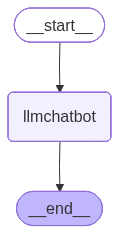

In [6]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
2==2

True

In [8]:
response = graph.invoke({"messages":"HI I'm Yogesh"})
print(response["messages"][-1].content)

<think>
Okay, the user just introduced themselves as Yogesh. I should respond warmly and ask how I can assist them. Keep it friendly and open-ended. Maybe add an emoji to keep the tone light. Let me make sure there's no need for further analysis here. Just a simple, welcoming reply.
</think>

Hi Yogesh! 👋 Nice to meet you! How can I assist you today? 😊


In [9]:
for event in graph.stream({"messages":["Hi How are you?","Please add 2+2", "I want to know your name"]}):
    for value in event.values():
        print("--------")
        print(value["messages"][-1].content)

--------
<think>
Okay, the user asked, "I want to know your name." Let me check the guidelines. They said I should respond in English unless the user asks otherwise. Also, they want me to be helpful and provide clear answers. 

First, I need to confirm the user's request. They want to know my name. In the previous interactions, I mentioned being Qwen. But maybe I should state it clearly again. The user might not remember or might be in a different conversation thread.

Wait, in the history, the first response was in Chinese, but the user is now asking for the name. The guidelines say to respond in the same language as the user. The user's latest query is in English, so I should respond in English.

Also, the user might be testing if I can handle multiple languages. Since the current query is in English, switching to English is appropriate. I should state my name clearly as Qwen and mention my capabilities to be helpful. Keep it friendly and concise.

Double-check the guidelines: no mar

## Chatbot with TOOL 🤖

In [10]:

from langchain_tavily import TavilySearch
tool = TavilySearch(max_results=2)

def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

tools=[tool,multiply]
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

    

_ChatModelBinding(bound=ChatGroq(metadata={'versions': {'langchain-core': '1.4.6', 'langchain': '1.3.7'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x11f841fd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11f842a50>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accura

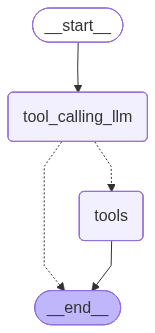

In [11]:
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
def tool_calling_llm(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)

builder.add_edge("tools", END)

graph= builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
response=graph.invoke({"messages":"current time in delhi,india"})

In [13]:
response['messages'][-1].content

'{"query": "current time in delhi, india", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://time.savvycal.com/worldclock/India/Delhi/New_Delhi", "title": "Current Local Time in New Delhi, Delhi, India", "content": "New Delhi, India is in the Asia/Kolkata time zone (IST), currently UTC+05:30. New Delhi stays at UTC+05", "score": 0.89997756, "raw_content": null}, {"url": "https://www.worldometers.info/time/new-delhi-india", "title": "Time in New Delhi, India (LIVE)", "content": "Exact local time now in New Delhi, Delhi, India. Time Zone, UTC offset ... Current local time in New Delhi, Delhi, India. 12h24h. AnalogDigital. 08:05:18.", "score": 0.8891543, "raw_content": null}], "response_time": 0.94, "request_id": "50176f7b-2a78-4956-b7b4-7ecca9d604ee"}'

In [ ]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

current time in delhi,india
================================== Ai Message ==================================
Tool Calls:
  tavily_search (en0vzc3fb)
 Call ID: en0vzc3fb
  Args:
    query: current time in delhi, india
================================= Tool Message =================================
Name: tavily_search

{"query": "current time in delhi, india", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://time.savvycal.com/worldclock/India/Delhi/New_Delhi", "title": "Current Local Time in New Delhi, Delhi, India", "content": "New Delhi, India is in the Asia/Kolkata time zone (IST), currently UTC+05:30. New Delhi stays at UTC+05", "score": 0.89997756, "raw_content": null}, {"url": "https://www.worldometers.info/time/new-delhi-india", "title": "Time in New Delhi, India (LIVE)", "content": "Exact local time now in New Delhi, Delhi, India. Time Zone, UTC offset ... Curr

In [15]:
response=graph.invoke({"messages":"what is recent khan sir news on media?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is recent khan sir news on media?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (d0h97tgkp)
 Call ID: d0h97tgkp
  Args:
    query: recent Khan Sir news on media
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent Khan Sir news on media", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/p/DZoYLiCyoiL", "title": "Indian Media Got More Defamed by Defaming Khan Sir 💀🔥 ...", "content": "Indian media's ranking is 157 out of 180 countries. These media people turned Khan Sir into Faizal Khan in a single day. OCR. indian media world ranking 2026", "score": 0.47533798, "raw_content": null}, {"url": "https://www.youtube.com/watch?v=opyFuUqc-rI", "title": "Murde

## ReAct Agent Architecture 

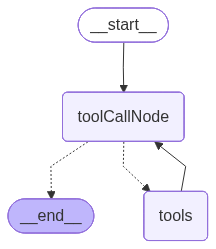

In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
def toolCallNode(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

# nodes
nodeBuilder = StateGraph(State)
##adding nodes
nodeBuilder.add_node("toolCallNode",toolCallNode)
nodeBuilder.add_node("tools",ToolNode(tools))

## adding edges

nodeBuilder.add_edge(START,"toolCallNode")
nodeBuilder.add_conditional_edges("toolCallNode",tools_condition)
nodeBuilder.add_edge("tools","toolCallNode")

newGraph = nodeBuilder.compile() 
from IPython.display import Image, display
display(Image(newGraph.get_graph().draw_mermaid_png()))

In [17]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (q03g7k0er)
 Call ID: q03g7k0er
  Args:
    query: recent AI news
    time_range: day
  multiply (70y5w450a)
 Call ID: 70y5w450a
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/ai", "title": "Artificial Intelligence - Latest AI News and Analysis - WSJ.com", "content": "AI Is Turbocharging the Spamosphere, Amping Up Prolific Text-Message Scams · Google sued swindlers accused in losses totaling $1.9 billion. By. Robert McMillan.", "score": 0.73023266, "raw_content": null}, {"url": "https://m.economictimes.com/tech/artificial-intelligence"

### Adding MemoryIn Agentic Graph

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
def toolCallNode(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

# nodes
nodeBuilder = StateGraph(State)
##adding nodes
nodeBuilder.add_node("toolCallNode",toolCallNode)
nodeBuilder.add_node("tools",ToolNode(tools))

## adding edges

nodeBuilder.add_edge(START,"toolCallNode")
nodeBuilder.add_conditional_edges("toolCallNode",tools_condition)
nodeBuilder.add_edge("tools","toolCallNode")

newGraph = nodeBuilder.compile(checkpointer=memory) 


config={"configurable":{"thread_id":"1"}}

response = newGraph.invoke({"messages":"Hey, My Name is Yogesh"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey, My Name is Yogesh
================================== Ai Message ==================================

Hello Yogesh! It's nice to meet you. How can I assist you today? 😊


In [19]:
response = newGraph.invoke({"messages":"what is my name?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey, My Name is Yogesh
================================== Ai Message ==================================

Hello Yogesh! It's nice to meet you. How can I assist you today? 😊
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Yogesh. 😊 Let me know how I can assist you!


In [20]:
response = newGraph.invoke({"messages":"Hey, My Name is Sumit?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey, My Name is Yogesh
================================== Ai Message ==================================

Hello Yogesh! It's nice to meet you. How can I assist you today? 😊
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Yogesh. 😊 Let me know how I can assist you!
================================ Human Message =================================

Hey, My Name is Sumit?
================================== Ai Message ==================================

Hello Sumit! It's nice to meet you. How can I assist you today? 😊


## Streaming

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

- In LangGraph, streaming is used to get results incrementally as the graph executes, instead of waiting for the entire workflow to finish.

Why use streaming?
- Real-time visibility into graph execution

- When a graph contains multiple nodes (LLM calls, tools, agents, etc.), execution can take time. Streaming lets you see what happens after each node completes.

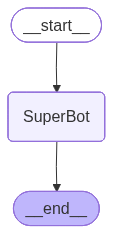

In [26]:

from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
def super_bot(state:State):
    return {
        "messages":[llm.invoke(state["messages"])]
    }
graph = StateGraph(State)
#node
graph.add_node("SuperBot", super_bot)
##edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot", END)
graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [30]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Yogesh And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Yogesh And I like cricket', additional_kwargs={}, response_metadata={}, id='d2269b8a-143b-4a97-9da5-97ac880bbaee'),
  HumanMessage(content='Hi,My name is Yogesh And I like cricket', additional_kwargs={}, response_metadata={}, id='0e60c007-01e4-4180-ac7c-ca8c25c15574'),
  AIMessage(content='Hello Yogesh! 👋 Great to meet you.  \n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into watching the matches, playing yourself, or maybe both? Let me know, and we can chat about anything cricket‑related!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Yogerg And I like cricket". Likely they just greeting. Should respond politely. Maybe ask about cricket preferences. No disallowed content. So answer friendly.'}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 97, 'total_tokens': 206, 'completion_time': 0.226387174, 'completion_tokens_details': {'reasoning_

In [34]:
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Yogesh And I like football"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Yogesh! 👋 Nice to meet you again.  \n\nSince you mentioned you like football, is there something specific you’d like to talk about—your favorite team, a recent match, player stats, training tips, or maybe a fun football‑related question? Let me know what you’re interested in and we’ll dive right in!', additional_kwargs={'reasoning_content': "The user keeps repeating same phrase. Likely they want a response acknowledging. Could ask what they'd like. Keep conversation. Provide friendly response."}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 409, 'total_tokens': 516, 'completion_time': 0.230560019, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.022186691, 'prompt_tokens_details': None, 'queue_time': 0.323751091, 'total_time': 0.25274671}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': No

In [ ]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({'messages':"Hi I'm Yogesh , I also like f1 car racing"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Yogesh And I like football', additional_kwargs={}, response_metadata={}, id='38142add-49e2-4b6a-8494-2590edb062ad'), AIMessage(content="Hello Yogesh! 👋 Great to meet you. \n\nYou mentioned you like football—do you have a favorite team or league you follow? Are you more into watching matches, playing the game yourself, or maybe both? I'd love to hear more!", additional_kwargs={'reasoning_content': 'We need to respond. The user just says hi, introduces themselves. We should greet them, ask about football preferences perhaps. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 82, 'total_tokens': 171, 'completion_time': 0.187591869, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.003567415, 'prompt_tokens_details': None, 'queue_time': 0.286665535, 'total_time': 0.191159284}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_dema

In [39]:
config = {"configurable": {"thread_id": "4"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Yogesh and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Yogesh and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ed451-df66-7fa0-82d7-446a50eb7962', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='f8730b96-dd67-4102-9736-6255833d57f7'), AIMessage(content='Hey Krish! 👋 Great to meet you. How’s cricket going? Do you have a favorite format—Test, ODI, T20—or a particular team you root for? I’d love to hear more about your cricket adventures!', additional_kwargs={'reasoning_content': 'The user says "Hi My name is Krish and I like to play cricket". Probably they just want a response. We can greet them, ask about cricket. No disallowed content. So respond friendly.'}, response_metadata={'finish_reason': 'stop', 'model_name': 'openai/gpt-